FD-q格式是一种基于有限差分法的高精度格式。它本质上在于保持差分法构造的高精度的同时，为了控制边界上的精度失真行为如何加密网格的算法。对应于一种针对于q阶格式的配置点格式。以下则简单介绍其原理和构造方法。

## Chebyshev配置点的精度

### Chebyshev配置点
Chebyshev配置点有两种，一种叫做Chebyshev roots，其分布为：
$$ y_i = -\cos(\frac{(2i - 1)\pi}{2N}), \quad i=1, 2, ..., N$$
另一种分布叫Chebyshev extrama，其分布为：
$$ x_i = -\cos(\frac{i\pi}{N}), \quad i=0, 1, 2, ..., N$$
Chebyshev可看作为基于给定配置点的满点模板的有限差分法，其格式可以利用拉格朗日插值法等给出。

### Chebyshev配置点的精度
以Chebyshev roots为例，对应给定的目标点$y_i的$拉格朗日法函数约定为I_i(x)，其误差函数系数为
$$
\pi(x) = \prod \limits_{i=1}^N(x-y_i)
$$
不难按照Chebyshev roots得到在整个$[-1, 1]$计算域中的$\pi(x)$绝对值的分布

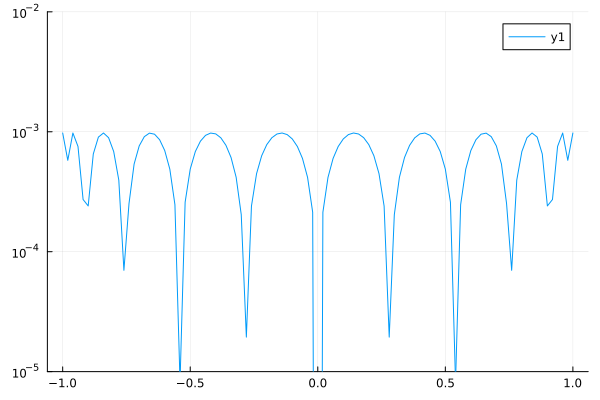

In [1]:
using Plots

function pi_x(x, y)
    nsize, = size(y)
    prod = 1.0e0
    for i in 1:length(y)
        prod = prod*(x-y[i])
    end
    return prod
end

N = 11
y = Array{Float64}(undef, N)
x = Array{Float64}(undef, N+1)
for i = 1:N
    y[i] = -cos((2*i-1)/(2*N)*pi)
end
for i = 1:N+1
    x[i] = -cos((i-1)*pi/N)
end

pos = range(-1, 1, 101)
abs_pi = Array{Float64}(undef, 101)
for i in 1:101
    abs_pi[i] = max(abs(pi_x(pos[i], y)), 1e-15)
end

plot(pos, abs_pi, ylims=(1e-5,1e-2), yscale=:log10)

# abs_pi_extrama = Array{Float64}(undef, N+1)
# for i in 1:N+1
#     abs_pi_extrama[i] = abs(pi_x(x[i], y))
# end
# plot(x, abs_pi_extrama, ylims=(1e-5,1e-2))
# @show [x abs_pi_extrama]


如果选用Chebyshev extrama配置点，可以看到其误差系数函数$|\pi(x)|$分布为：

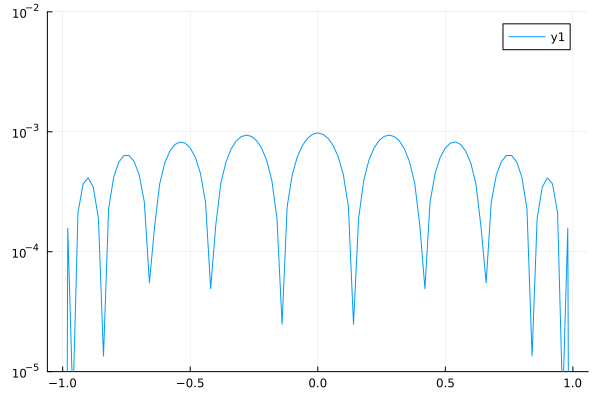

In [2]:
pos = range(-1, 1, 101)
abs_pi = Array{Float64}(undef, 101)
for i in 1:101
    abs_pi[i] = max(abs(pi_x(pos[i], x)), 1e-15)
end

plot(pos, abs_pi, ylims=(1e-5,1e-2), yscale=:log10)

作为比较，也不难给出如果是等间距网格情况下的误差系数分布。

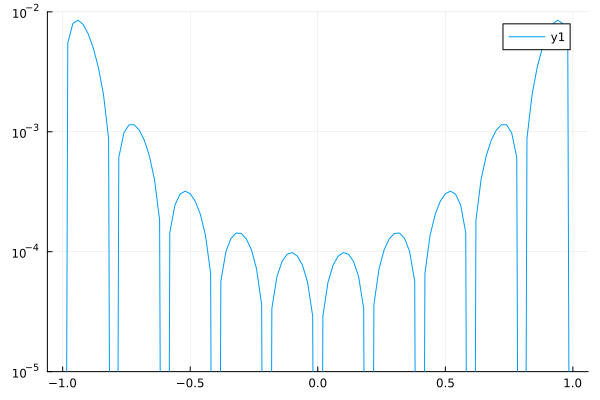

In [3]:
N = 11
x_eq = range(-1, 1, N)

pos = range(-1, 1, 101)
abs_pi = Array{Float64}(undef, 101)
for i in 1:101
    abs_pi[i] = max(abs(pi_x(pos[i], x_eq)), 1e-15)
    
end

plot(pos, abs_pi, ylims=(1e-5,1e-2), yscale=:log10)

可见，当选择chebyshev roots时，对应的最大$|pi|$值都相等，不会出现龙格效应。如果采用等间距网格，则在边界附近易出现很大误差，即龙格效应。但选取Chebyshev roots也有缺点，该选点并不包含两个边界上的点(-1和1)，故可以选取Chebyshev extrama，虽然无法做到等误差分布，但是依然可以很好的抑制边界处的误差。同时，还可以很容易证明，对于Chebyshev roots构造的误差系数函数，Chebyshev extrama的配置点恰好都位于最大值处。

## 构造任意q阶的配置点
按照前面的分析，可见可以根据误差系数函数最大值相等的位置构造任意精度的配置点，从而保证边界处不失真。
故可以设计如下算法来构造配置点以及q阶配置点下的有限差分法。其步骤为：
1. 选取任意N个在$[-1，1]$区域内的有序节点$y_1, y_2, ..., y_N$，并基于拉格朗日插值模板在每个点上构造$q-1$阶的多项式插值；
2. 在以上构造的N个$q-1$阶多项式的误差系数函数$\pi_i(x)$中，选取其中的第1到第N-1个，可以选取在$[y_i, y_{i+1})$的函数极值位置，记此时的极值点对应的$x$为$x_1, x_2, ..., x_{N-1}$，即：
   $$
   \pi^\prime_i(x_i) = 0, \quad i=1, 2, ..., N-1
   $$
   这些点与两个边界上的$x_0=-1, x_N=1$共同构成配置点位置；
3. 以误差系数函数极值的模相等为约束条件，迭代给出$y_i$的位置，并最终确定配置点$x_i$的分布，即需要在配置点上满足如下条件：
   $$
   |\pi_1(x_0)|=|\pi_1(x_1)|=|\pi_2(x_2)|=...=|\pi_{N-1}(x_{N-1})|=|\pi_{N-1}(x_N)|
   $$；
4. 利用得到的配置点重新构造$q$阶多项式，从而确定差分格式并给出求导系数矩阵。


对应代码如下：

In [2]:
using Polynomials, GenericLinearAlgebra, SparseArrays, LinearAlgebra

struct LagrangePolynomial
    order::Int64
    p_0
end

function construct_lagrange_polynomial(x)
    p_0 = Array{Polynomial, 1}(undef, length(x))
    for i in 1:length(x)
        p_0[i] = Polynomial([-x[i], 1])
    end
    lagrange_polynomial=LagrangePolynomial(length(x)-1, p_0)
    return lagrange_polynomial
end

function polyval(poly::LagrangePolynomial, x)
    return prod([poly.p_0[i](x) for i in 1:length(poly.p_0)])
end

#返回x0到x1中的极值
function find_extreme(poly::LagrangePolynomial, x0, x1)

    xrange=range(x0, x1, length=11)
    idx = 0
    while (xrange[end]-xrange[begin])>eps(1.0e0)*20.0e0
        y=[polyval(poly, x) for x in xrange]
        value, idx=findmax(abs.(y))
        xrange=range(xrange[max(idx-1, 1)], xrange[min(idx+1, 11)], length=11)
    end
    return xrange[idx]
end


find_extreme (generic function with 1 method)

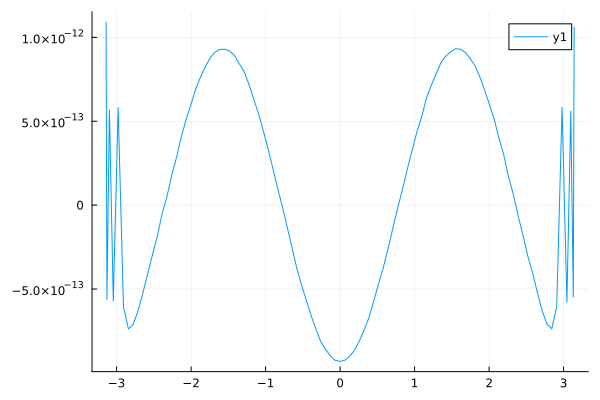

In [42]:
#
using Plots

module FDqScheme

    using Polynomials, GenericLinearAlgebra, SparseArrays, LinearAlgebra

    struct LagrangePolynomial
        order::Int64
        p_0
    end

    function construct_lagrange_polynomial(x)
        p_0 = Array{Polynomial, 1}(undef, length(x))
        for i in 1:length(x)
            p_0[i] = Polynomial([-x[i], 1])
        end
        lagrange_polynomial=LagrangePolynomial(length(x)-1, p_0)
        return lagrange_polynomial
    end

    function polyval(poly::LagrangePolynomial, x)
        return prod([poly.p_0[i](x) for i in 1:length(poly.p_0)])
    end

    #返回x0到x1中的极值
    function find_extreme(poly::LagrangePolynomial, x0, x1)

        xrange=range(x0, x1, length=11)
        idx = 0
        while (xrange[end]-xrange[begin])>eps(1.0e0)*20.0e0
            y=[polyval(poly, x) for x in xrange]
            value, idx=findmax(abs.(y))
            xrange=range(xrange[max(idx-1, 1)], xrange[min(idx+1, 11)], length=11)
        end
        return xrange[idx]
    end


    function lagrange_pi(poly::LagrangePolynomial, x, xi)
        # lagrange_pi=LagrangePolynomial(poly.order, poly.p_0)
        lagrange_pi = LagrangePolynomial(poly.order, [poly.p_0[i] for i in 1:poly.order+1])
        lagrange_pi.p_0[findall(x->x==xi, x)].=Polynomial([1.0e0])
        return lagrange_pi
    end

    function derivative_lagrange_pi(poly::LagrangePolynomial, x)

        lagrange_pi=LagrangePolynomial(poly.order, [poly.p_0[i] for i in 1:poly.order+1])
        derivative_lagrange_pi = 0.0e0
        for i in 1:poly.order+1
            derivative_langrange_pi_local = 1.0e0
            for j in 1:poly.order+1
                if j!=i
                    derivative_langrange_pi_local = derivative_langrange_pi_local*poly.p_0[j](x)
                    # @show j, poly.p_0[j](x)
                else
                    derivative_langrange_pi_local = derivative_langrange_pi_local*derivative(poly.p_0[j])(x)
                    # @show j, derivative(poly.p_0[j])(x)
                end
            end
            # @show derivative_langrange_pi_local
            derivative_lagrange_pi=derivative_lagrange_pi + derivative_langrange_pi_local
        end
        return derivative_lagrange_pi
    end

    function LagrangeScheme(x, x0)
        pi0=construct_lagrange_polynomial(x)
        iloc = findall(x->x==x0, x)[1]
        LagrangeScheme=[]
        for i in 1:length(x)
            push!(LagrangeScheme, 
                derivative_lagrange_pi(lagrange_pi(pi0, x, x[i]), x[iloc])/polyval(lagrange_pi(pi0, x, x[i]), x[i]))
        end
        return LagrangeScheme
    end

    #construct q order interpolation of degree q-1
    function construct_si(N, q)
        N = N - 1
        si=[]
        if isodd(q)
            for i in 1:Int32((q-1)/2)
                push!(si, 0)
            end
            for i in 0:N-q
                push!(si, i)
            end
            for i in 1:Int32((q+1)/2)
                push!(si, N-q)
            end
        else
            for i in 1:Int32(q/2)
                push!(si, 0)
            end
            for i in 0:N-q
                push!(si, i)
            end
            for i in 1:Int32(q/2)
                push!(si, N-q)
            end
        end
        return reshape(Int64.(si), N+1, :)
    end

    # return a matrix for a distributed nodes in a section
    function construct_schemes(x::Vector, q)
        n = length(x)
        si = construct_si(n, q) .+ 1
        scheme_matrix = zeros(n, n)
        for i in 1:n
            scheme_matrix[i, si[i]:si[i]+q]=LagrangeScheme(x[si[i]:si[i]+q], x[i])
        end
        return sparse(scheme_matrix)
    end

    #construct_polynomial factor pi_y
    function construct_polynomial(y, N, q, si)
        pi_y = Array{LagrangePolynomial}(undef, N-1)
        for i in 1:N-1
            pi_y[i] = construct_lagrange_polynomial(y[si[i]+1:si[i]+q+1])
        end
        return pi_y
    end

    # search_extrema_xi
    function search_extrema_xi(y, pi_y, N)
        x=Array{Float64}(undef, N+1)
        x[1] = -1#*Float64(N)
        x[end] = 1#*Float64(N)
        for i in 1:N-1
            x[i+1] = find_extreme(pi_y[i], y[i], y[i+1])
        end
        return x
    end

    #get_f
    function get_f(y, N, q, si, x, flg=true)
        #construct_polynomial factor pi_y
            pi_y = construct_polynomial(y, N, q-1, si)
        # search extrema xi
        if flg
            x_extrema = search_extrema_xi(y, pi_y, N)
        else
            x_extrema = x
        end
        #return abs(pi(x)) at xi
        abs_pi_x = []

        push!(abs_pi_x, abs(polyval(pi_y[1], x_extrema[1])))
        for i in 1:N-1
            push!(abs_pi_x, abs(polyval(pi_y[i], x_extrema[i+1])))
        end
        push!(abs_pi_x, abs(polyval(pi_y[N-1], x_extrema[N+1])))

        f= []
        for i in 1:N
            push!(f, abs_pi_x[i+1]-abs_pi_x[i])
        end
        return Float64.(f), Float64.(x_extrema), pi_y
    end

    function construct_J(y, x, f, N, q, si)
        epsilon = sqrt(eps(1.0e0))
        ymin = 1.0e-6
        J = zeros(N, N)

        for i in 1:N
            h = zeros(N)
            if abs(y[i])>ymin
                h[i] = epsilon*y[i]
            else
                h[i] = ymin*sign(y[i]+eps(1.0e0))
            end
            y_new=y+h
            f_new, = get_f(y_new, N, q, si, x, false)
            J[:, i] = (f_new-f)/h[i]
        end
        return sparse(J)
    end


    function FD_q_Scheme(n, q_target)

        N = n - 1

        # guess y_i using q=N, equal space
        y = Array{Float64}(undef, N)
        for i in 1:N
            y[i] = (2.0e0/Float64(2N)-1.0e0+2.0e0/Float64(N)*Float64(i-1))
        end

        x=zeros(N+1)

        for q in 2:1:q_target
            si = construct_si(N, q-1)

            f, x, pi_y= get_f(y, N, q, si, x)

            maxdy = 1.0e0
            while maxdy > 2.2e-6
                J = construct_J(y, x, f, N, q, si)
                dy = - J\f

                if(y+dy!=sort(vec(y+dy))) 
                    @show J
                    @show J[1, 1], J[end, end]
                    sleep()
                end
                y = y+ dy
                f, x= get_f(y, N, q, si, x)
                maxdy = maximum(abs.(dy))
            end
        end

        return x, construct_schemes(collect(x), q_target)
    end

end

import .FDqScheme

x, D=FDqScheme.FD_q_Scheme(101, 10)

plot(x*pi, (Dx/pi)*sin.(2x*pi)-2cos.(2x*pi))

In [25]:
for i=1:101
    D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
end
for i=1:101
    # x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
    # if x[i]>40
    #     x[i]=40
    # end
    x = 10
end

In [43]:
for i=1:101
    x[i] = 10 * x[i] .+ 10
end
D = 0.1 * D

101×101 SparseArrays.SparseMatrixCSC{Float64, Int64} with 1111 stored entries:
⎡⣿⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣷⣄⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢸⣿⣿⣿⣿⎦

In [44]:
x

101-element Vector{Float64}:
  0.0
  0.03670485304617088
  0.14313492149357288
  0.3085506288651594
  0.5160081802074394
  0.7432779230464135
  0.9546832505341456
  1.1574886002110318
  1.3609904931325705
  1.566308300575713
  ⋮
 18.639009506524104
 18.842511398154315
 19.0453167485706
 19.25672207680988
 19.483991819275452
 19.69144937021814
 19.85686507869009
 19.9632951464622
 20.0

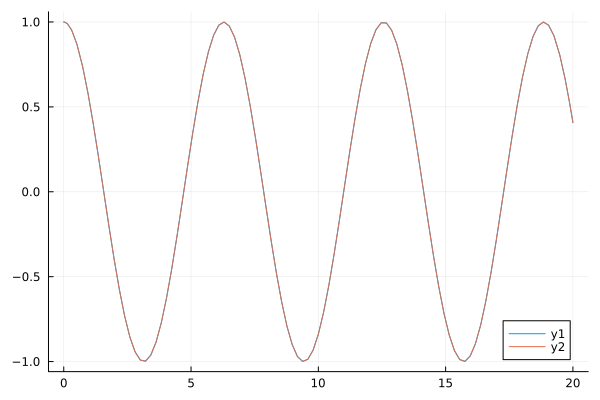

In [45]:
y = sin.(x)
dy = cos.(x)
dy1 = D*y
plot(x, dy)
plot!(x,dy1)